# 激活函数

上一章揭示了一个根本性的问题：**无论叠加多少层线性变换，整体仍然是线性的**，本质上等价于单层网络。增加层数无法带来更强的表达能力。

要让多层网络真正发挥威力，必须在层与层之间引入**非线性**（Nonlinearity）。完成这个任务的组件，就是**激活函数**（Activation Function）。

激活函数紧跟在线性变换之后，对中间值施加一个非线性操作。这个操作打破了层与层之间的线性叠加关系，使得网络可以学习输入与输出之间复杂的非线性规律。

``💡 通用近似定理（Universal Approximation Theorem）：数学证明，一个至少包含一个隐藏层且使用非线性激活函数的网络，可以以任意精度逼近任何连续函数。这是深度学习表达能力的理论基础。``

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(99)

## 数据集

与前几章相同，直接沿用。

### 训练数据：特征、标签

In [2]:
train_features = np.array([[22.5, 72.0],
                           [31.4, 45.0],
                           [19.8, 85.0],
                           [27.6, 63.0]])
train_labels = np.array([[95],
                         [210],
                         [70],
                         [155]])

### 测试数据：特征、标签

In [3]:
test_features = np.array([[28.1, 58.0]])
test_labels = np.array([[165]])

## 模型

参数初始化与上一章相同。本章新增 ReLU 激活函数及其反向函数。

### 参数：隐藏层权重、偏置

In [4]:
hidden_weight = np.random.rand(4, 2) / 2
hidden_bias   = np.random.rand(4)

### 参数：输出层权重、偏置

In [5]:
output_weight = np.random.rand(1, 4) / 4
output_bias   = np.random.rand(1)

### 推理函数

In [6]:
def forward(x, w, b):
    return x @ w.T + b

### ReLU 激活函数

**线性整流函数**（Rectified Linear Unit，ReLU）是目前最常用的隐藏层激活函数。它的规则极为简单：

$$
\text{ReLU}(x) = \max(0,\ x)
$$

即：负数归零，正数保持不变。

ReLU 的优点：

* **计算高效**：只需一次阈值比较，运算快；
* **抑制无效信号**：将负值截断为 0，相当于过滤掉对输出没有贡献的信息；
* **缓解梯度消失**：在正数区间导数恒为 1，梯度通过时不被削弱。

``💡 梯度消失（Vanishing Gradient）是深层网络训练中的经典难题：反向传播时，梯度需要连乘多层的导数，如果每层的导数都小于 1，经过多层连乘后梯度会趋近于 0，导致靠近输入的层几乎无法更新参数。ReLU 的正数区间导数恒为 1，避免了这个问题。``

In [7]:
def relu(x):
    return np.maximum(0, x)

ReLU 激活函数的图像：

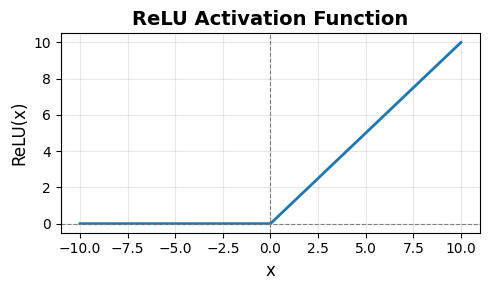

In [8]:
x_range = np.linspace(-10, 10, 200)
plt.figure(figsize=(5, 3))
plt.plot(x_range, relu(x_range), linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel('ReLU(x)', fontsize=12)
plt.title('ReLU Activation Function', fontsize=14, fontweight='bold')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 损失函数（均方误差）

In [9]:
def mse_loss(p, y):
    return np.mean(np.square(y - p))

### 梯度函数

In [10]:
def gradient(p, y):
    return -2 * (y - p) / len(y)

### 梯度反向函数

In [11]:
def gradient_backward(d, w):
    return d @ w

### ReLU 反向函数

ReLU 加入前向传播后，反向传播中也需要对应的导数，称为 **ReLU 反向函数**。

ReLU 的导数是：

$$
\frac{d\,\text{ReLU}}{dx} =
\begin{cases}
1 & x > 0 \\
0 & x \leq 0
\end{cases}
$$

在链式规则中，ReLU 反向函数的完整作用是：

$$
\frac{\partial L}{\partial z} = \frac{\partial L}{\partial h} \cdot \frac{d\,\text{ReLU}}{dz} = \underbrace{d_1}_{\text{gradient\_backward}} \cdot \mathbb{1}[z > 0]
$$

其中 $z$ 是 ReLU 之前的中间值（pre-ReLU），$h = \text{ReLU}(z)$ 是 ReLU 之后的输出（post-ReLU）。

实现时，我们传入 post-ReLU 值 $h$ 来判断 $> 0$。这与用 pre-ReLU 值 $z$ 判断完全等价，因为 $h > 0 \iff z > 0$（ReLU 不改变正数的值，只把负数截断为 0）。

In [12]:
def relu_backward(h, d):
    return (h > 0) * d

### 反向函数

In [13]:
def backward(x, d, w, b, lr):
    w -= d.T @ x * lr
    b -= np.sum(d, axis=0) * lr
    return w, b

## 训练

### 超参数：学习率

In [14]:
LEARNING_RATE = 0.00001

### 超参数：批大小

In [15]:
BATCH_SIZE = 2

### 超参数：轮数

In [16]:
EPOCHS = 1000

### 迭代

引入 ReLU 后，训练循环的数据流如下：

1. **前向传播链路**：线性变换 → ReLU → 线性变换 → 预测值

```{figure} images/layer-relu-forward.png
:align: center
:width: 520px

* $x$：特征值；$w_1, b_1$：隐藏层参数；$h$：post-ReLU 中间值；$w_2, b_2$：输出层参数；$p$：预测值。

```

2. **梯度计算链路**：损失函数导数 → 梯度反向函数 → ReLU 反向函数 → 隐藏层误差项

```{figure} images/layer-relu-gradient.png
:align: center
:width: 600px

* $d_2$：输出层误差项；$w_2$：输出层权重；$h$：post-ReLU 中间值；$d_1$：隐藏层误差项。

```

3. **反向传播链路**：与上一章相同，激活函数不产生新的参数，不影响参数更新步骤。

```{figure} images/layer-backward.png
:align: center
:width: 240px

```

``💡 通常在数值回归任务中，输出层不加激活函数，让预测值可以取任意实数。后续的分类任务中，输出层会使用 Softmax 等激活函数将输出转化为概率。``

In [17]:
for epoch in range(EPOCHS):
    for i in range(0, len(train_features), BATCH_SIZE):
        features = train_features[i: i + BATCH_SIZE]
        labels   = train_labels[i: i + BATCH_SIZE]

        # 前向传播：隐藏层线性变换 → ReLU → 输出层线性变换
        hidden      = relu(forward(features, hidden_weight, hidden_bias))
        predictions = forward(hidden, output_weight, output_bias)

        # 梯度计算：输出层误差 → 梯度反向 → ReLU 反向 → 隐藏层误差
        output_delta = gradient(predictions, labels)
        hidden_delta = relu_backward(
            hidden,
            gradient_backward(output_delta, output_weight)
        )

        # 反向传播：先更新输出层，再更新隐藏层
        output_weight, output_bias = backward(hidden,    output_delta, output_weight, output_bias, LEARNING_RATE)
        hidden_weight, hidden_bias = backward(features,  hidden_delta, hidden_weight, hidden_bias, LEARNING_RATE)

print(f'output weight: {output_weight}')
print(f'output bias:   {output_bias}')

output weight: [[1.39916537 1.43560331 1.96797648 0.69705886]]
output bias:   [1.00887392]


## 验证

### 推理

测试时前向传播也需要经过 ReLU。

In [18]:
hidden      = relu(forward(test_features, hidden_weight, hidden_bias))
predictions = forward(hidden, output_weight, output_bias)
print(f'predictions: {predictions}')

predictions: [[164.86381116]]


### 评估

In [19]:
loss = mse_loss(predictions, test_labels)
print(f'loss: {loss:.4f}')

loss: 0.0185


加入 ReLU 后，1000 轮训练的最终损失从上一章的 `2.51` 骤降至 `0.019`，预测值 164.86 与真实值 165 相差不到 0.2 个冰激凌。

## 结束语

至此，我们从零开始，完整构建了一个包含隐藏层、批处理、多轮训练和 ReLU 激活函数的多层神经网络。从一个单神经元出发，每章只引入一个新概念，最终实现了一个真正意义上的深度学习模型。

回顾这个过程，你会发现随着网络层数的增加，**梯度计算和反向传播变得越来越繁琐**：

* 每增加一层，就需要手写一套对应的导数推导和反向函数；
* 激活函数、损失函数的变化，都会牵动整个反向传播链路的改写；
* 代码量和出错概率随层数呈线性增长。

这种手工推导方式在教学上有不可替代的价值——它让我们深刻理解了梯度是如何在网络中流动的。但在实际工程中，它并不可行。

**下一部分**，我们将从头构建一个自己的神经网络训练框架，实现前向传播、梯度计算和反向传播的**自动化**（即自动微分，Automatic Differentiation）。有了这个框架，无论网络多深、结构多复杂，只需定义前向传播，框架会自动完成所有梯度计算和参数更新。这也是 PyTorch、TensorFlow 等现代深度学习库的核心机制。

## 课后练习

在训练循环中，每 100 轮打印一次 ReLU 激活函数截了多少负的中间值。观察随着训练进行，这个比例如何变化？